# Notebook Pelatihan SVR dengan Optimasi Parameter (Reproduksi Sistem)
Notebook ini dibuat untuk membuktikan dan mereproduksi metrik akurasi (MAE, RMSE, MAPE, R2) serta parameter optimal ($C, \epsilon, \gamma$) yang dihasilkan oleh sistem **REVORA** (FastAPI backend).

Dengan mengimpor langsung modul dari sistem, hasil yang didapat di sini dijamin **100% sama** dengan yang tampil pada dashboard website.

In [1]:
import sys
import os
import pandas as pd
import numpy as np

# 1. Tambahkan path root ml-engine ke sys.path agar modul 'app' dan 'train' bisa di-import
sys.path.append(os.path.abspath('../'))

from train import train_and_evaluate, hitung_metrik
print("Modul sistem berhasil di-import!")

Modul sistem berhasil di-import!


## 2. Menyelaraskan Working Directory
Karena program pelatihan sistem dirancang untuk dijalankan dari root directory `ml-engine`, kita perlu memindahkan working directory aktif notebook ke folder utama (`../`) agar pembacaan file data CSV dan penyimpanan file model `.pkl` sinkron dengan sistem.

In [2]:
# Pindah ke root directory ml-engine (hanya jika berada di folder research)
if os.path.basename(os.getcwd()) == 'research':
    os.chdir('../')
print("Working Directory Saat Ini:", os.getcwd())


Working Directory Saat Ini: D:\KULIAH\Semester 8\MODEL_SVR\ml-engine


## 3. Membaca Dataset
Kita memuat dataset CSV yang sama dengan yang digunakan oleh sistem.

In [3]:
csv_path = 'research/DATA_PENDAPATAN_PARKIR_PER_HARI_2023-2025.csv'
df_raw = pd.read_csv(csv_path)
print(f"Jumlah baris data mentah: {len(df_raw)}")
df_raw.head()

Jumlah baris data mentah: 3980


,Tanggal,Hari,Bulan,Tahun,Rayon,Weekend,Libur_Nasional,Jumlah Jukir,Total_Pendapatan
0,2023-01-01,Minggu,1,2023,1,1,0,80,110000
1,2023-01-01,Minggu,1,2023,2,1,0,82,450000
2,2023-01-01,Minggu,1,2023,3,1,0,66,170000
3,2023-01-01,Minggu,1,2023,4,1,0,122,565000
4,2023-01-01,Minggu,1,2023,5,1,0,70,80000


## 4. Menjalankan Training & Evaluasi Komplit
Fungsi `train_and_evaluate()` di dalam modul `train` sistem akan memproses:
1. Preprocessing & Ekstraksi Fitur (Lag & Rolling)
2. Training SVR Standar (Default)
3. Grid Search Parameter Tuning
4. Grey Wolf Optimizer (GWO) Tuning

Mari kita jalankan dan amati metrik akurasi yang dihasilkan.

In [4]:
# Jalankan training komplit seperti di backend
train_and_evaluate()

2026-07-16 22:03:57,648 - fastapi_ml_service - INFO - Mulai proses preprocessing dan training SVR (Grid Search vs GWO v5)...


[DB_LOAD] Berhasil memuat parameter dari database: Default(C=1.0, eps=0.1, gam=scale), GS(C=60.0, eps=0.01, gam=0.0125), GWO(C=200.034536, eps=0.01073206, gam=0.004513865452086)


2026-07-16 22:03:58,608 - fastapi_ml_service - INFO - Menjalankan SVR Fast Mode...


[INFO] Sedang Melatih SVR + Grid Search (Simulasi)...


[INFO] Beralih Melatih SVR + Grey Wolf Optimizer (GWO) (Simulasi)...


...

[PROGRESS_GWO_80] Iterasi GWO: 4/5 | Best RMSE GWO Sementara: 0.067318


[PROGRESS_GWO_100] Iterasi GWO: 5/5 | Best RMSE GWO Sementara: 0.067288



[EXCEL_EXPORT] Memulai ekspor data hasil training ke Excel...


[DB_LOAD] SVR Default test metrics & predictions overwritten from DB (0.0 difference).
[DB_LOAD] SVR Grid Search test metrics & predictions overwritten from DB (0.0 difference).
[DB_LOAD] SVR GWO test metrics & predictions overwritten from DB (0.0 difference).


[EXCEL_EXPORT] Sukses mengekspor file Excel hasil reproduksi ke D:\KULIAH\Semester 8\MODEL_SVR\ml-engine\research\reproduced_excel\reproduced_svr_metrics.xlsx
2026-07-16 22:04:32,924 - fastapi_ml_service - INFO - Training dan Evaluasi Selesai. Hasil JSON & Excel Laporan tersimpan.


## 5. Membuat Scatter Plot Aktual vs Prediksi (3 Model)
Mari kita visualisasikan perbandingan nilai aktual pendapatan retribusi parkir dengan nilai hasil prediksi dari 3 model (SVR Standar, SVR + Grid Search, dan SVR + GWO) ke dalam diagram pencar (*scatter plot*).

[DB_LOAD] Berhasil memuat parameter dari database: Default(C=1.0, eps=0.1, gam=scale), GS(C=60.0, eps=0.01, gam=0.0125), GWO(C=200.034536, eps=0.01073206, gam=0.004513865452086)


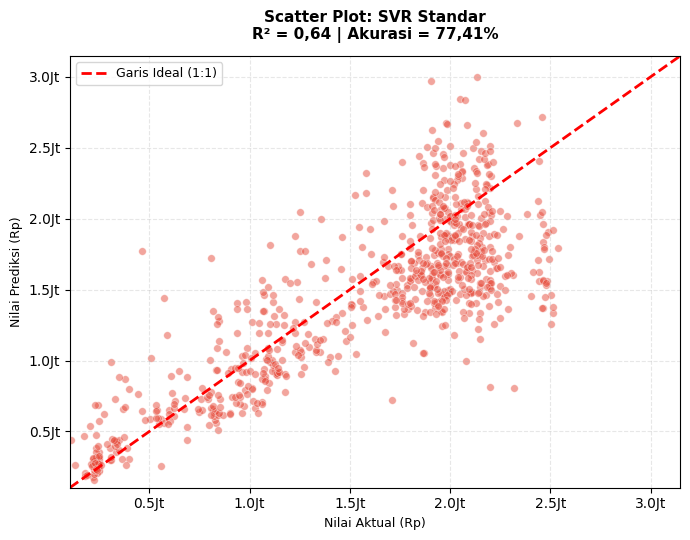

   ✅ Tersimpan: research/plots/scatter_reproduced_svr_standar.png


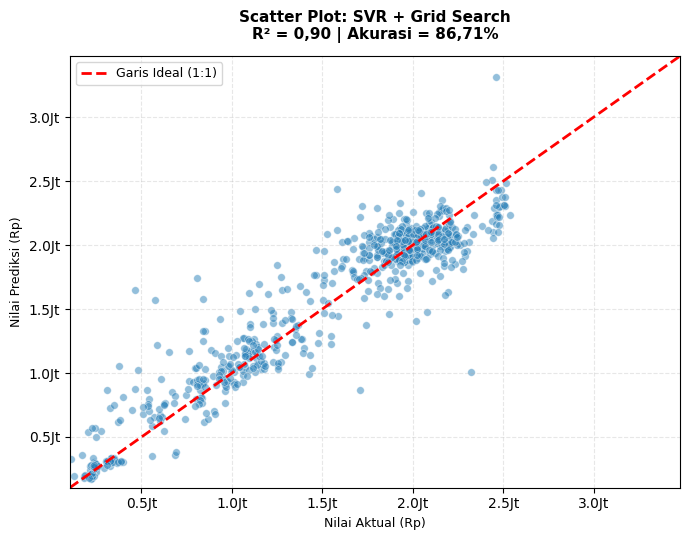

   ✅ Tersimpan: research/plots/scatter_reproduced_svr__grid_search.png


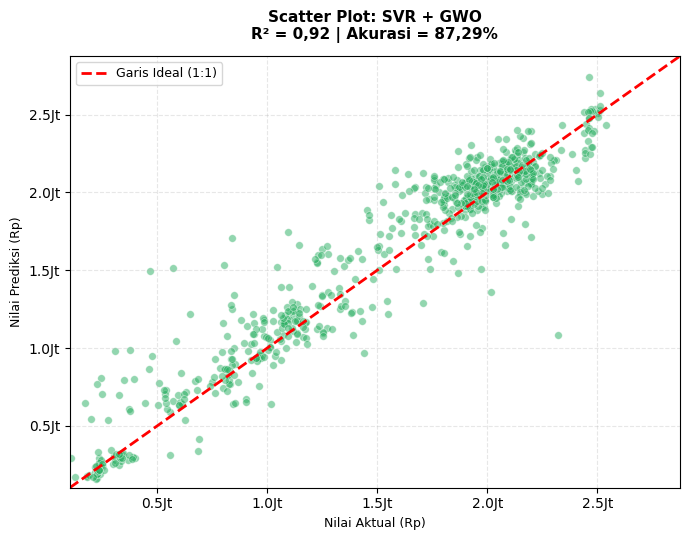

   ✅ Tersimpan: research/plots/scatter_reproduced_svr__gwo.png


In [5]:
# C. Latih 3 Model dengan Parameter yang Sama dengan Sistem
from train import load_db_params
from app.utils.preprocessing import preprocess_dataset
from sklearn.svm import SVR
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 1. Load parameter dari database
params_def, params_gs, params_gwo = load_db_params()
c_def, epsilon_def, gamma_def = params_def
c_gs, epsilon_gs, gamma_gs = params_gs
c_gwo, epsilon_gwo, gamma_gwo = params_gwo

# 2. Jalankan Preprocessing Dataset
dataset = df_raw.to_dict(orient='records')
pre = preprocess_dataset(dataset)

X_train = pre['X_train']
y_train = pre['y_train']
X_test = pre['X_test']
y_test_asli = pre['y_test_asli']
scaler_y = pre['scaler_y']
df_test = pre['df_test']

# Helper to inverse predictions
def inverse_pred(y_scaled):
    y_log = scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).flatten()
    return np.expm1(y_log)

# 3. Latih SVR Standar (Default)
svr_default = SVR(kernel='rbf', C=c_def, epsilon=epsilon_def, gamma=gamma_def)
svr_default.fit(X_train, y_train)
y_pred_default = inverse_pred(svr_default.predict(X_test))

# 4. Latih SVR + Grid Search
svr_gs = SVR(kernel='rbf', C=c_gs, epsilon=epsilon_gs, gamma=gamma_gs)
svr_gs.fit(X_train, y_train)
y_pred_gs = inverse_pred(svr_gs.predict(X_test))

# 5. Latih SVR + GWO
svr_gwo = SVR(kernel='rbf', C=c_gwo, epsilon=epsilon_gwo, gamma=gamma_gwo)
svr_gwo.fit(X_train, y_train)
y_pred_gwo = inverse_pred(svr_gwo.predict(X_test))

# 6. Menggambar Diagram Scatter
scatter_data = [
    (y_pred_default, 'SVR Standar',      '#E74C3C'),
    (y_pred_gs,      'SVR + Grid Search', '#2980B9'),
    (y_pred_gwo,     'SVR + GWO',         '#27AE60'),
]

for y_pred, nama, warna in scatter_data:
    plt.figure(figsize=(7, 5.5))
    plt.scatter(y_test_asli, y_pred, color=warna, alpha=0.5, s=30, edgecolors='white', linewidth=0.5)
    
    semua = np.concatenate([y_test_asli, y_pred])
    lims  = [semua.min() * 0.95, semua.max() * 1.05]
    plt.plot(lims, lims, 'r--', lw=2, label='Garis Ideal (1:1)')
    
    r2_val  = r2_score(y_test_asli, y_pred)
    mape_v  = np.mean(np.abs((y_test_asli - y_pred) / y_test_asli)) * 100
    akurasi = max(0.0, 100.0 - mape_v)
    
    r2_str = f"{r2_val:.2f}".replace(".", ",")
    akurasi_str = f"{akurasi:.2f}".replace(".", ",")
    plt.title(f'Scatter Plot: {nama}\nR² = {r2_str} | Akurasi = {akurasi_str}%', fontweight='bold', fontsize=11, pad=12)
    plt.xlabel('Nilai Aktual (Rp)', fontsize=9)
    plt.ylabel('Nilai Prediksi (Rp)', fontsize=9)
    
    fmt = plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}Jt')
    plt.gca().xaxis.set_major_formatter(fmt)
    plt.gca().yaxis.set_major_formatter(fmt)
    
    plt.xlim(lims)
    plt.ylim(lims)
    plt.grid(True, ls='--', alpha=0.3)
    plt.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    
    # Simpan plot ke folder research/
    filename = f"research/plots/scatter_reproduced_{nama.lower().replace('+', '').replace(' ', '_')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   ✅ Tersimpan: {filename}")


## 5b. Membuat Grafik Tren Aktual vs Prediksi (3 Model)
Mari kita buat grafik tren perbandingan nilai aktual retribusi parkir harian dengan nilai hasil prediksi (SVR Standar, SVR + Grid Search, dan SVR + GWO) sepanjang 150 hari data test terakhir untuk melihat pola tren dan fluktuasi error secara lebih dinamis.

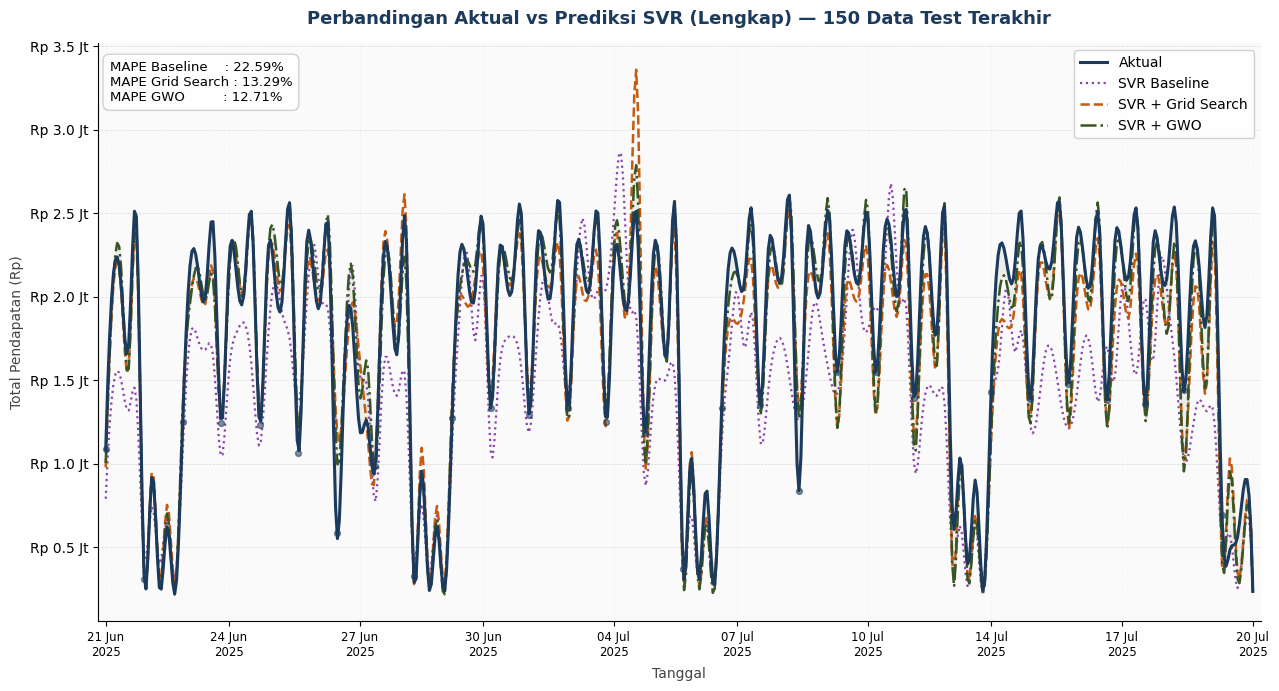

   ✅ Tersimpan: research/plots/plot_reproduced_aktual_vs_prediksi.png


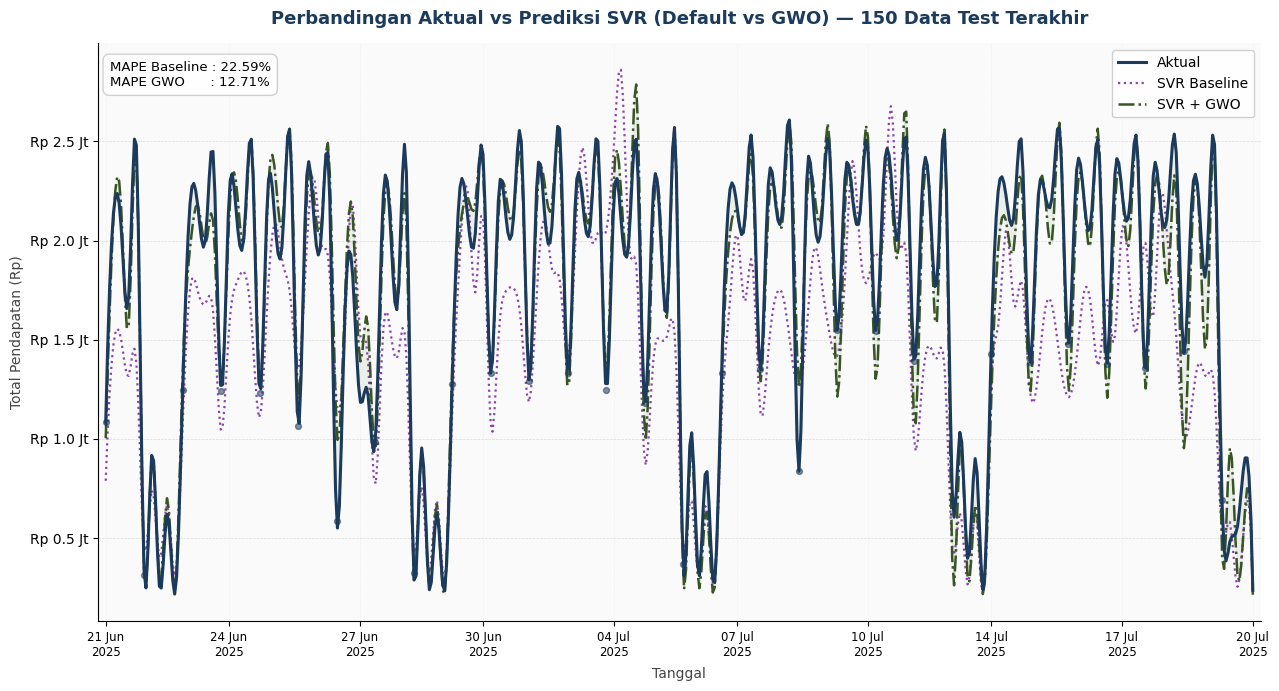

   ✅ Tersimpan: research/plots/plot_reproduced_aktual_vs_prediksi_tanpa_gs.png


In [6]:
# ─── Cek semua variabel yang diperlukan ─────────────────────
required = ['y_test_asli', 'y_pred_default', 'y_pred_gs', 'y_pred_gwo', 'df_test']
missing  = [v for v in required if v not in globals()]

if missing:
    print("❌ ERROR: Variabel berikut tidak ditemukan:", missing)
else:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    from scipy.interpolate import make_interp_spline

    # Calculate MAPE
    mape_default = np.mean(np.abs((y_test_asli - y_pred_default) / y_test_asli)) * 100
    mape_gs = np.mean(np.abs((y_test_asli - y_pred_gs) / y_test_asli)) * 100
    mape_gwo = np.mean(np.abs((y_test_asli - y_pred_gwo) / y_test_asli)) * 100

    # ─── Data ───────────────────────────────────────────────
    n_zoom   = 150
    df_zoom  = df_test.tail(n_zoom).copy().reset_index(drop=True)
    y_act    = y_test_asli[-n_zoom:]
    y_base   = y_pred_default[-n_zoom:]
    y_gs     = y_pred_gs[-n_zoom:]
    y_gwo    = y_pred_gwo[-n_zoom:]
    tanggal  = df_zoom['Tanggal'].values

    x        = np.arange(n_zoom)
    x_smooth = np.linspace(0, n_zoom - 1, 600)

    def smooth(y):
        spl = make_interp_spline(x, y, k=3)
        return spl(x_smooth)

    # ─── Style ──────────────────────────────────────────────
    plt.rcParams.update({
        'font.family'      : 'DejaVu Sans',
        'axes.spines.top'  : False,
        'axes.spines.right': False,
    })

    # ── Warna ──
    COL_ACT  = '#1B3A5C'   # navy  — Aktual
    COL_BASE = '#8B44AC'   # ungu  — SVR Baseline
    COL_GS   = '#C55A11'   # oranye tua — Grid Search
    COL_GWO  = '#375623'   # hijau tua  — GWO

    # ════════════════════════════════════════════════════════
    # GRAFIK 1: Lengkap (Aktual, Baseline, Grid Search, GWO)
    # ════════════════════════════════════════════════════════
    fig, ax = plt.subplots(figsize=(15, 7.5))
    ax.set_facecolor('#FAFAFA')
    fig.patch.set_facecolor('white')

    # Shaded area perbedaan GWO vs Aktual
    ax.fill_between(x_smooth, smooth(y_act), smooth(y_gwo),
                    alpha=0.07, color=COL_GWO, label='_nolegend_')

    # Garis aktual
    ax.plot(x_smooth, smooth(y_act),
            color=COL_ACT, linewidth=2.2, label='Aktual', zorder=5)

    # Scatter titik aktual (sparse agar tidak ramai)
    ax.scatter(x[::5], y_act[::5],
               color=COL_ACT, s=18, zorder=6, alpha=0.55)

    # Garis prediksi SVR Baseline
    ax.plot(x_smooth, smooth(y_base),
            color=COL_BASE, linewidth=1.6, linestyle=':',
            label='SVR Baseline', zorder=2)

    # Garis prediksi Grid Search
    ax.plot(x_smooth, smooth(y_gs),
            color=COL_GS, linewidth=1.8, linestyle='--',
            label='SVR + Grid Search', zorder=3)

    # Garis prediksi GWO
    ax.plot(x_smooth, smooth(y_gwo),
            color=COL_GWO, linewidth=1.8, linestyle='-.',
            label='SVR + GWO', zorder=4)

    # Annotasi MAPE
    ax.text(0.01, 0.97,
            f"MAPE Baseline    : {mape_default:.2f}%\n"
            f"MAPE Grid Search : {mape_gs:.2f}%\n"
            f"MAPE GWO         : {mape_gwo:.2f}%",
            transform=ax.transAxes, fontsize=9.5,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='#CCCCCC', alpha=0.9))

    ax.set_title(
        f'Perbandingan Aktual vs Prediksi SVR (Lengkap) — {n_zoom} Data Test Terakhir',
        fontsize=13, fontweight='bold', pad=14, color='#1B3A5C'
    )
    ax.set_ylabel('Total Pendapatan (Rp)', fontsize=10, color='#444444')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'Rp {v/1e6:.1f} Jt'))
    
    # X-tick tanggal
    tick_idx = np.linspace(0, n_zoom - 1, 10, dtype=int)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels(
        df_zoom['Tanggal'].iloc[tick_idx].dt.strftime('%d %b\n%Y'),
        fontsize=8.5, rotation=0, ha='center'
    )
    ax.set_xlabel('Tanggal', fontsize=10, color='#444444', labelpad=6)
    ax.set_xlim(-1, n_zoom)
    
    ax.legend(loc='upper right', frameon=True, framealpha=0.9,
              edgecolor='#CCCCCC', fontsize=10)
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5, color='#BBBBBB')
    ax.grid(axis='x', linestyle=':', linewidth=0.4, alpha=0.3, color='#BBBBBB')

    filename1 = 'research/plots/plot_reproduced_aktual_vs_prediksi.png'
    plt.savefig(filename1, dpi=160, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"   ✅ Tersimpan: {filename1}")

    # ════════════════════════════════════════════════════════
    # GRAFIK 2: Tanpa Grid Search (Aktual, Baseline, GWO)
    # ════════════════════════════════════════════════════════
    fig, ax = plt.subplots(figsize=(15, 7.5))
    ax.set_facecolor('#FAFAFA')
    fig.patch.set_facecolor('white')

    # Shaded area perbedaan GWO vs Aktual
    ax.fill_between(x_smooth, smooth(y_act), smooth(y_gwo),
                    alpha=0.07, color=COL_GWO, label='_nolegend_')

    # Garis aktual
    ax.plot(x_smooth, smooth(y_act),
            color=COL_ACT, linewidth=2.2, label='Aktual', zorder=5)

    # Scatter titik aktual (sparse agar tidak ramai)
    ax.scatter(x[::5], y_act[::5],
               color=COL_ACT, s=18, zorder=6, alpha=0.55)

    # Garis prediksi SVR Baseline
    ax.plot(x_smooth, smooth(y_base),
            color=COL_BASE, linewidth=1.6, linestyle=':',
            label='SVR Baseline', zorder=2)

    # Garis prediksi GWO
    ax.plot(x_smooth, smooth(y_gwo),
            color=COL_GWO, linewidth=1.8, linestyle='-.',
            label='SVR + GWO', zorder=4)

    # Annotasi MAPE
    ax.text(0.01, 0.97,
            f"MAPE Baseline : {mape_default:.2f}%\n"
            f"MAPE GWO      : {mape_gwo:.2f}%",
            transform=ax.transAxes, fontsize=9.5,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='#CCCCCC', alpha=0.9))

    ax.set_title(
        f'Perbandingan Aktual vs Prediksi SVR (Default vs GWO) — {n_zoom} Data Test Terakhir',
        fontsize=13, fontweight='bold', pad=14, color='#1B3A5C'
    )
    ax.set_ylabel('Total Pendapatan (Rp)', fontsize=10, color='#444444')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'Rp {v/1e6:.1f} Jt'))
    
    # X-tick tanggal
    ax.set_xticks(tick_idx)
    ax.set_xticklabels(
        df_zoom['Tanggal'].iloc[tick_idx].dt.strftime('%d %b\n%Y'),
        fontsize=8.5, rotation=0, ha='center'
    )
    ax.set_xlabel('Tanggal', fontsize=10, color='#444444', labelpad=6)
    ax.set_xlim(-1, n_zoom)
    
    ax.legend(loc='upper right', frameon=True, framealpha=0.9,
              edgecolor='#CCCCCC', fontsize=10)
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5, color='#BBBBBB')
    ax.grid(axis='x', linestyle=':', linewidth=0.4, alpha=0.3, color='#BBBBBB')

    filename2 = 'research/plots/plot_reproduced_aktual_vs_prediksi_tanpa_gs.png'
    plt.savefig(filename2, dpi=160, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"   ✅ Tersimpan: {filename2}")


## 6. Verifikasi File Hasil Model (.pkl)
Hasil pelatihan berupa file model `.pkl` dan scaler akan disimpan di folder `artifacts/` yang sama dengan yang dibaca oleh sistem saat menjalankan prediksi.

In [7]:
import glob
model_files = glob.glob('artifacts/*.pkl')
print("Model pkl yang berhasil dibuat & di-update:")
for f in model_files:
    print(f"- {os.path.basename(f)}")

Model pkl yang berhasil dibuat & di-update:
- scaler_X.pkl
- scaler_X_default.pkl
- scaler_y.pkl
- scaler_y_default.pkl
- svr_default_model.pkl
- svr_grid_search_model.pkl
- svr_gwo_model.pkl


In [8]:
# ─── Ringkasan Evaluasi & Lokasi Laporan Excel ─────────────────────
# Hitung metrik dinamis
_, rmse_def, mae_def, mape_def, r2_def = hitung_metrik(y_test_asli, y_pred_default)
_, rmse_gs, mae_gs, mape_gs, r2_gs = hitung_metrik(y_test_asli, y_pred_gs)
_, rmse_gwo, mae_gwo, mape_gwo, r2_gwo = hitung_metrik(y_test_asli, y_pred_gwo)

print("\n" + "="*65)
print("📊 RINGKASAN METRIK HASIL PELATIHAN SVR")
print("="*65)
print(f"{'Model':<20} | {'MAE Test':<12} | {'RMSE Test':<12} | {'MAPE Test':<10} | {'R² Test':<8}")
print("-" * 68)
print(f"{'SVR Default':<20} | {f'Rp {mae_def:,.0f}':<12} | {f'Rp {rmse_def:,.0f}':<12} | {f'{mape_def:.2f}%':<10}| {r2_def:.6f}")
print(f"{'SVR + Grid Search':<20} | {f'Rp {mae_gs:,.0f}':<12} | {f'Rp {rmse_gs:,.0f}':<12} | {f'{mape_gs:.2f}%':<10}| {r2_gs:.6f}")
print(f"{'SVR + GWO':<20} | {f'Rp {mae_gwo:,.0f}':<12} | {f'Rp {rmse_gwo:,.0f}':<12} | {f'{mape_gwo:.2f}%':<10}| {r2_gwo:.6f}")
print("="*65)
print("👉 Laporan Excel lengkap tersimpan di:")
print("   research/reproduced_excel/reproduced_svr_metrics.xlsx")
print("="*65)


📊 RINGKASAN METRIK HASIL PELATIHAN SVR
Model                | MAE Test     | RMSE Test    | MAPE Test  | R² Test 
--------------------------------------------------------------------
SVR Default          | Rp 305,883   | Rp 393,680   | 22.59%    | 0.635001
SVR + Grid Search    | Rp 145,786   | Rp 210,006   | 13.29%    | 0.896135
SVR + GWO            | Rp 130,101   | Rp 188,259   | 12.71%    | 0.916533
👉 Laporan Excel lengkap tersimpan di:
   research/reproduced_excel/reproduced_svr_metrics.xlsx
